## Чтение и предобработка данных

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv("data/student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [ ]:
df.drop(columns=["Student_ID"], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [ ]:
df = df.rename(
    columns={
        "CGPA": "Efficiency",
        "Sleep_Duration": "Sleep",
        "Study_Hours": "Study",
        "Social_Media_Hours": "Social Media",
        "Physical_Activity": "Sport",
        "Stress_Level": "Stress",
    }
)
df.head()

,Age,Gender,Department,Efficiency,Sleep,Study,Social Media,Sport,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Обработка дубликатов строк

In [ ]:
print("До", df.shape)

df = df.drop_duplicates()

print("После", df.shape)

До (100000, 10)
После (100000, 10)


## Распределения

Найдено числовых признаков: 7



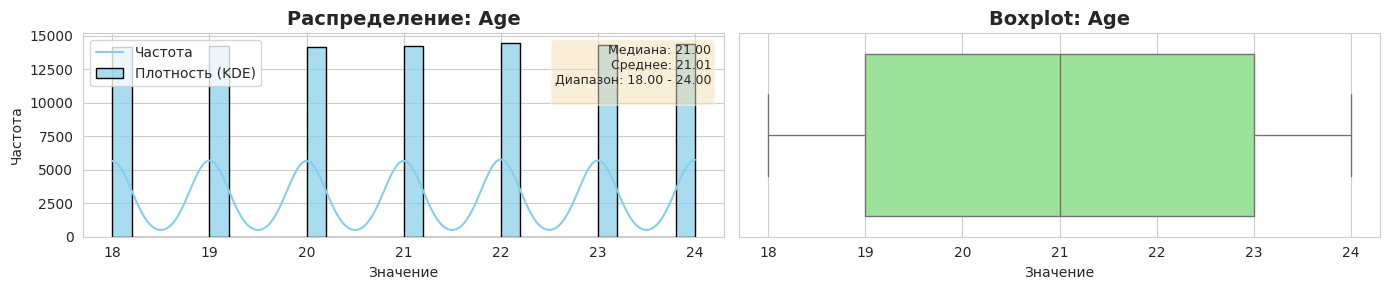

Выбросов (IQR) в Age: 0


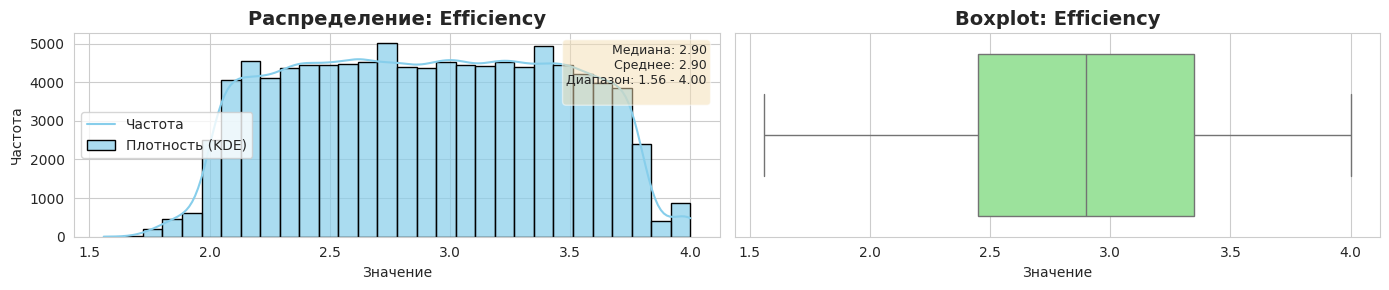

Выбросов (IQR) в Efficiency: 0


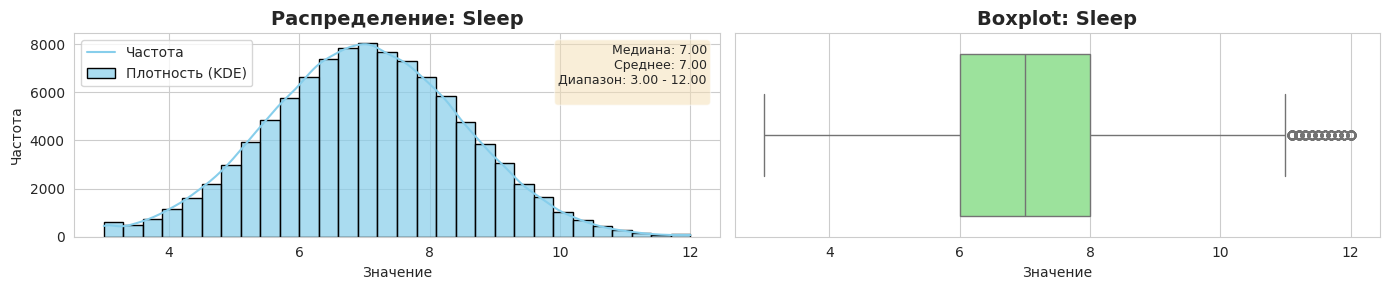

Выбросов (IQR) в Sleep: 369


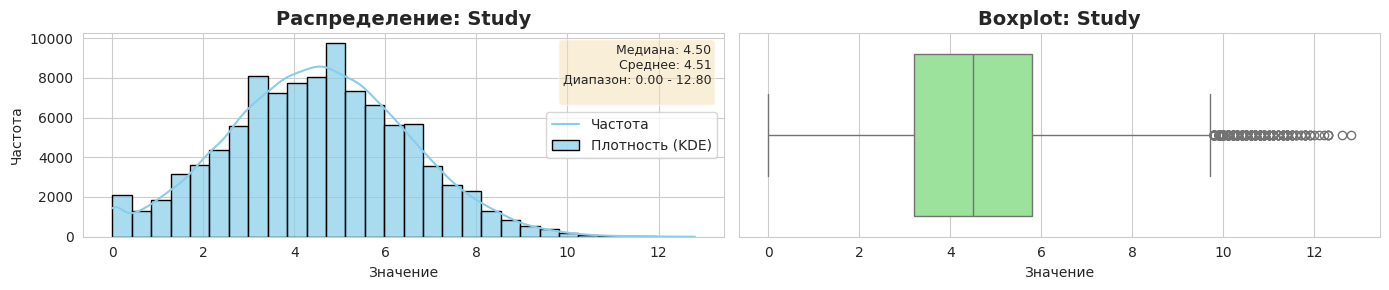

Выбросов (IQR) в Study: 432


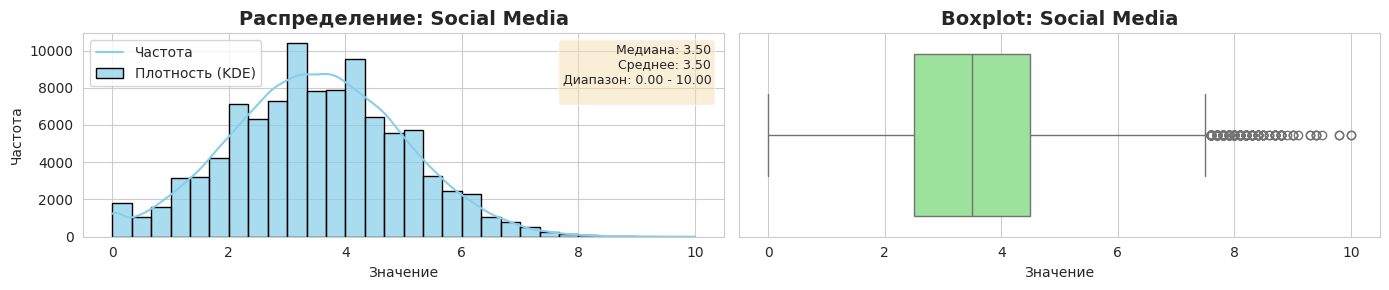

Выбросов (IQR) в Social Media: 328


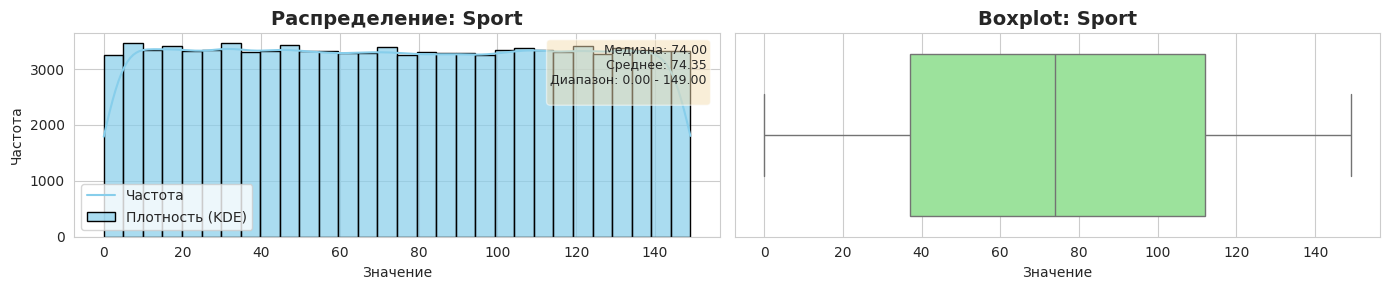

Выбросов (IQR) в Sport: 0


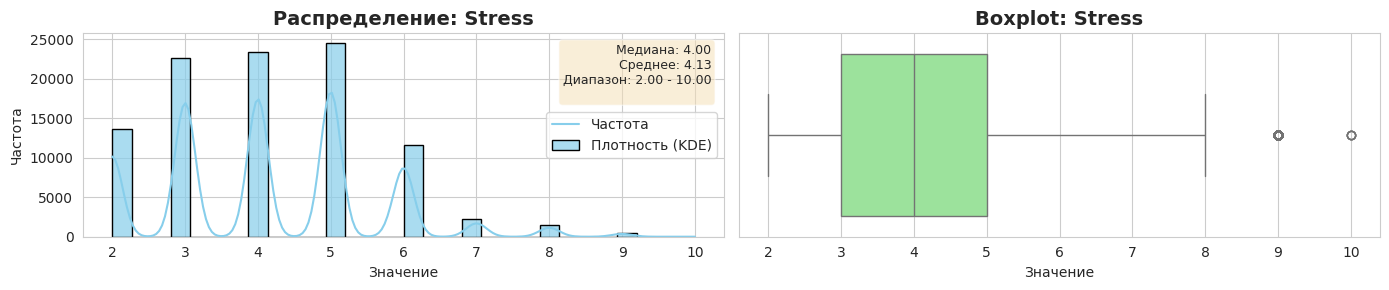

Выбросов (IQR) в Stress: 478


In [ ]:
# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (16, 5)

# Выбираем только числовые колонки
numeric_cols = df.select_dtypes(include="number").columns.to_list()

print(f"Найдено числовых признаков: {len(numeric_cols)}\n")

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    # Гистограмма + KDE
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[0],
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    axes[0].set_title(f"Распределение: {col}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Значение")
    axes[0].set_ylabel("Частота")
    axes[0].legend(["Частота", "Плотность (KDE)"], loc="best")

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1], color="lightgreen")
    axes[1].set_title(f"Boxplot: {col}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Значение")

    # Статистика
    stats_text = (
        f"Медиана: {df[col].median():.2f}\n"
        f"Среднее: {df[col].mean():.2f}\n"
        f"Диапазон: {df[col].min():.2f} - {df[col].max():.2f}\n"
    )

    axes[0].text(
        0.98,
        0.95,
        stats_text,
        transform=axes[0].transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()

    # Расчёт выбросов
    col_data = df[col]

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()

    # # Вывод в консоль
    print(f"Выбросов (IQR) в {col}: {outliers_count}")

Найдено категориальных признаков: 4
Признаки: ['Age', 'Gender', 'Department', 'Stress']
Оставшиеся числовые колонки: ['Sport', 'Efficiency', 'Study', 'Depression', 'Sleep', 'Social Media']



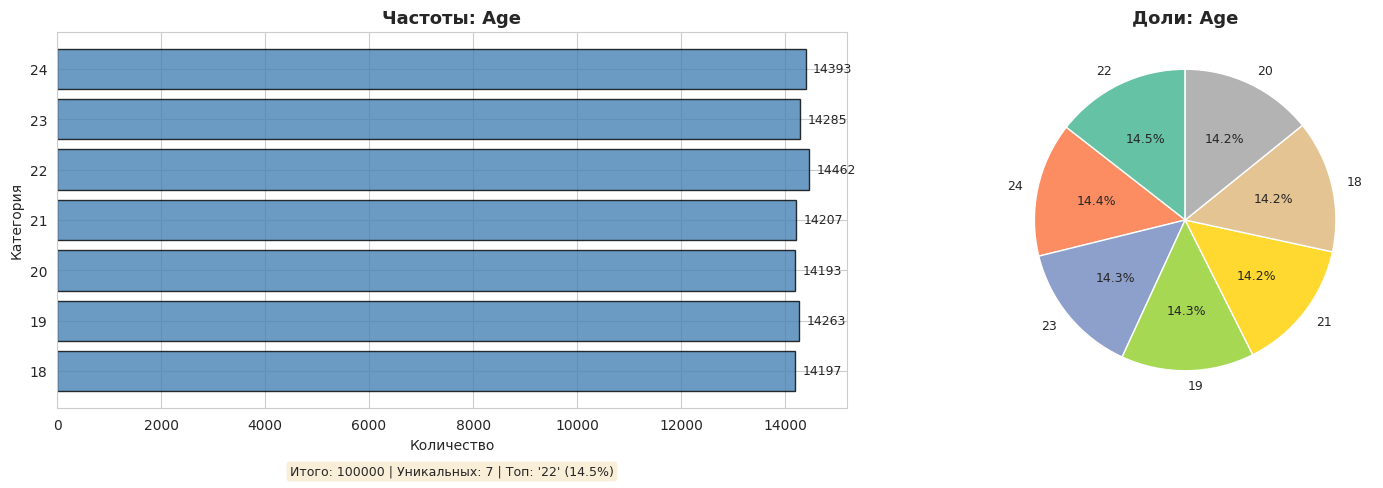

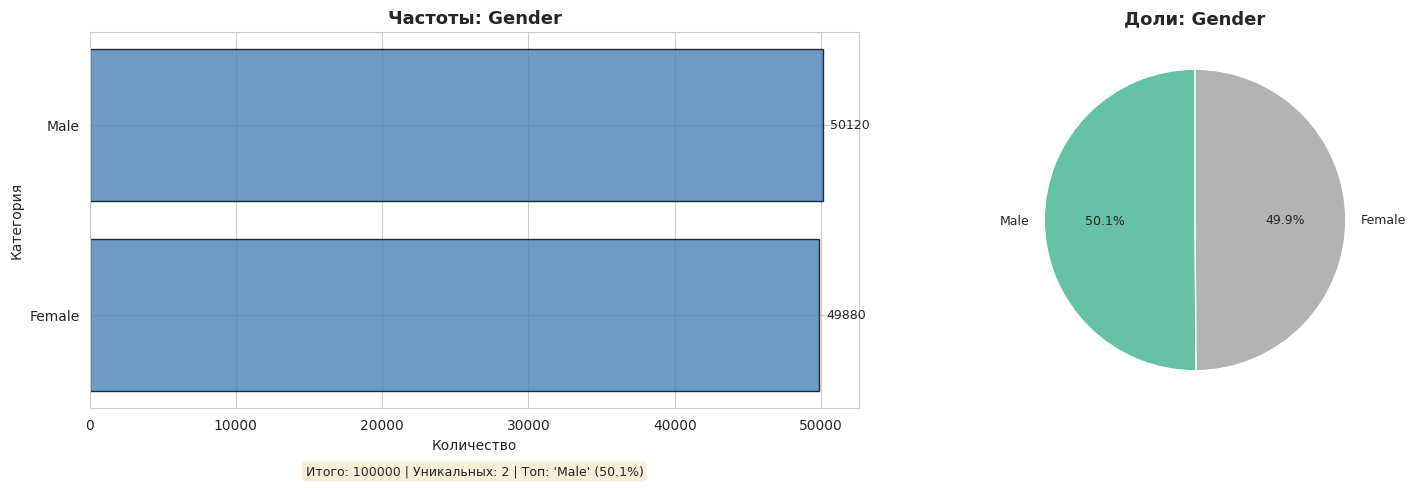

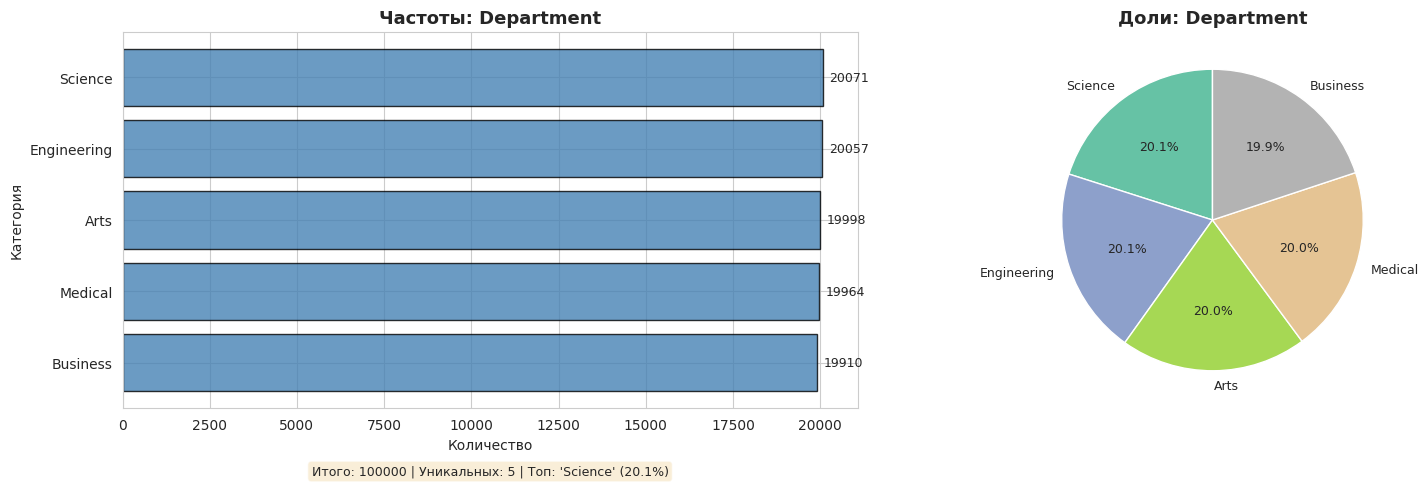

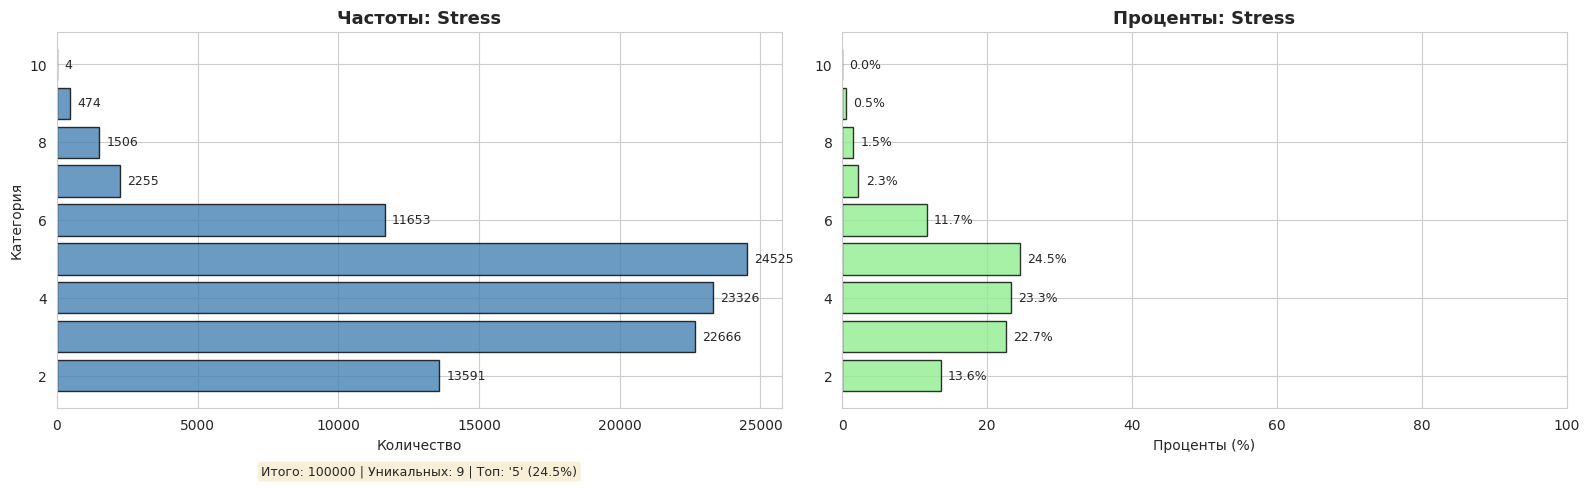

In [99]:
# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 5)

# Определяем категориальные признаки
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Добавить числовые колонки с малым числом уникальных значений
numeric_with_few_unique = [
    col
    for col in df.select_dtypes(include="number").columns
    if df[col].nunique() < 10 and df[col].nunique() > 1
]
cat_cols.extend(numeric_with_few_unique)

df[cat_cols] = df[cat_cols].astype("category")

print(f"Найдено категориальных признаков: {len(cat_cols)}")
print(f"Признаки: {cat_cols}")
print(f"Оставшиеся числовые колонки: {list(set(df.columns) - set(cat_cols))}\n")


def analyze_categorical(series: pd.Series, feature_name: str, top_n: int = 15):
    """Анализирует распределение категориального признака."""

    value_counts = series.value_counts()
    total_count = len(series)
    unique_count = len(value_counts)

    if unique_count > top_n:
        print(
            f"{feature_name}: {unique_count} уникальных категорий. Показываем первые топ-{top_n}"
        )
        other_count = (
            total_count - value_counts.head(top_n).sum()
        )  # Считаем сумму оставшихся
        value_counts = value_counts.head(top_n)
    else:
        other_count = 0

    # График Bar plot (aбсолютные частоты)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    bars = axes[0].barh(
        value_counts.index[::-1],
        value_counts[::-1],
        color="steelblue",
        edgecolor="black",
        alpha=0.8,
    )
    axes[0].set_title(f"Частоты: {feature_name}", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Количество")
    axes[0].set_ylabel("Категория")

    # Подписываем значения на столбцах (если их не слишком много)
    if len(value_counts) <= 10:
        for bar in bars:
            width = bar.get_width()
            axes[0].text(
                width + max(value_counts.values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{int(width)}",
                va="center",
                fontsize=9,
            )

    # График Pie chart с процентами (только для <= 7 категорий)
    if len(value_counts) <= 7:
        colors = plt.cm.Set2(np.linspace(0, 1, len(value_counts)))
        wedges, texts, autotexts = axes[1].pie(
            value_counts.values,
            labels=value_counts.index,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors,
            textprops={"fontsize": 9},
        )

        axes[1].set_title(f"Доли: {feature_name}", fontsize=13, fontweight="bold")
    else:
        # Графки Bar plot с процентами, если категорий много
        percentages = value_counts / total_count * 100
        bars = axes[1].barh(
            percentages.index[::-1],
            percentages.values[::-1],
            color="lightgreen",
            edgecolor="black",
            alpha=0.8,
        )
        axes[1].set_title(f"Проценты: {feature_name}", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Проценты (%)")
        axes[1].set_xlim(0, 100)

        # Подписываем проценты
        for bar in bars:
            width = bar.get_width()
            axes[1].text(
                width + 1,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                va="center",
                fontsize=9,
            )

    # Статистика на графике
    stats_text = (
        f"Итого: {total_count}\n"
        f"Уникальных: {unique_count}\n"
        f"Топ: '{value_counts.index[0]}' ({value_counts.values[0] / total_count * 100:.1f}%)"
    )

    if other_count > 0:
        stats_text += (
            f"\nНе показано: {other_count} ({other_count / total_count * 100:.1f}%)"
        )

    axes[0].text(
        0.5,
        -0.15,
        stats_text.replace("\n", " | "),
        transform=axes[0].transAxes,
        fontsize=9,
        ha="center",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()


if not cat_cols:
    print("Категориальные признаки не найдены.")
else:
    for col in cat_cols:
        analyze_categorical(df[col], col, top_n=12)

In [100]:
from typing import Literal


def find_strong_correlations(corr_matrix, threshold=0.7):
    """Находит пары признаков с |корреляцией| >= threshold"""
    strong_pairs = []
    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) >= threshold:
                strong_pairs.append(
                    {
                        "feature_1": columns[i],
                        "feature_2": columns[j],
                        "correlation": corr_val,
                        "strength": "positive" if corr_val > 0 else "negative",
                    }
                )

    strong_df = pd.DataFrame(
        strong_pairs, columns=["feature_1", "feature_2", "correlation", "strength"]
    )

    if not strong_df.empty:
        strong_df = strong_df.sort_values("correlation", key=abs, ascending=False)

    return strong_df


def plot_correlation_heatmap(
    df: pd.DataFrame,
    target_col: str | None = None,
    method: Literal["pearson", "spearman", "kendall"] = "pearson",
    threshold: float = 0.7,
):
    """Построение heatmap корреляций + анализ связей с таргетом"""

    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr(method=method)

    # Heatmap
    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        square=True,
        linewidths=0.5,
    )
    plt.title(f"Heatmap корреляций ({method})", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # Если есть таргет, то показываем корреляции с ним
    if target_col and target_col in corr.columns:
        target_corr = (
            corr[target_col].drop(target_col).sort_values(ascending=False, key=abs)
        )
        print(f"\nКорреляции с '{target_col}' (по убыванию |r|):")
        for feat, val in target_corr.items():
            print(f"  {feat:20s}: {val:+.3f}")

    # Сильные корреляции между признаками
    strong = find_strong_correlations(corr, threshold)
    if not strong.empty:
        print(f"\nПары с |корреляцией| >= {threshold}:")
        print(strong.to_string(index=False))

    return corr

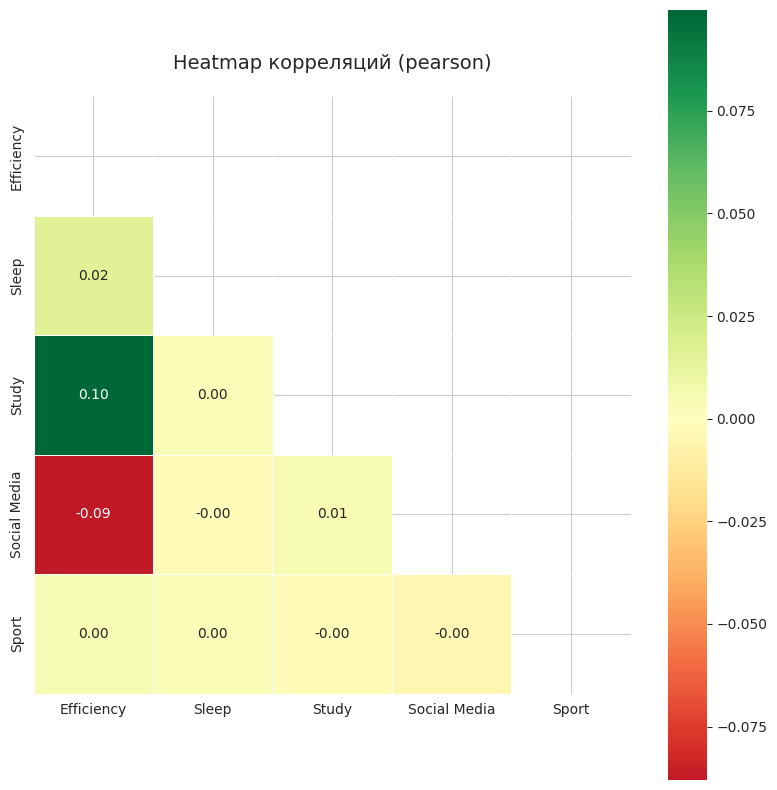

,Efficiency,Sleep,Study,Social Media,Sport
Efficiency,1.000000,0.015386,0.099534,-0.087998,0.004766
Sleep,0.015386,1.000000,0.002744,-0.003008,0.003166
Study,0.099534,0.002744,1.000000,0.005308,-0.002045
Social Media,-0.087998,-0.003008,0.005308,1.000000,-0.004788
Sport,0.004766,0.003166,-0.002045,-0.004788,1.000000


In [ ]:
plot_correlation_heatmap(df, target_col="Efficiency", method="pearson")

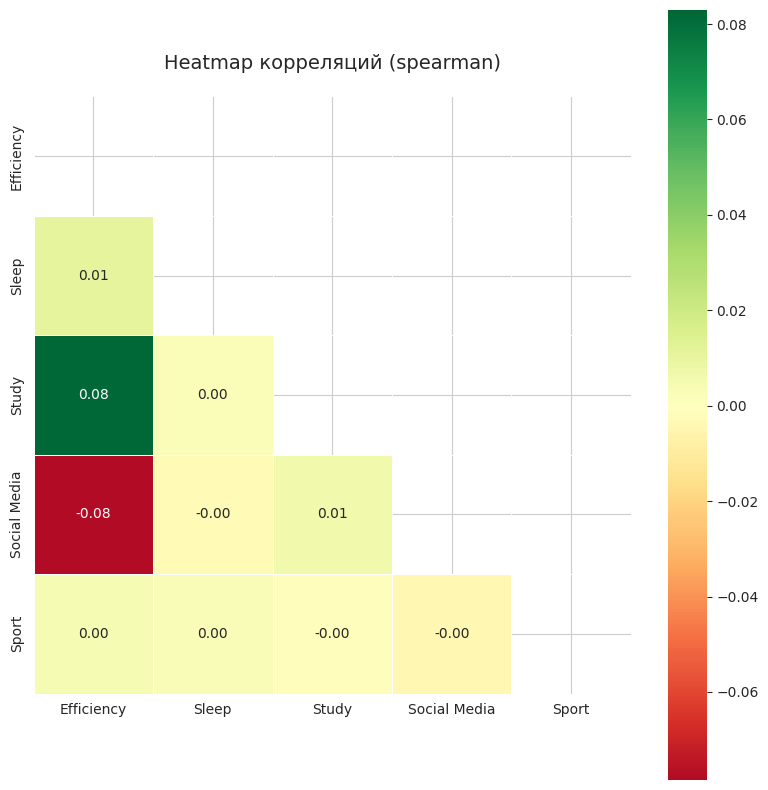

,Efficiency,Sleep,Study,Social Media,Sport
Efficiency,1.000000,0.010703,0.082950,-0.078449,0.004595
Sleep,0.010703,1.000000,0.002590,-0.003109,0.003462
Study,0.082950,0.002590,1.000000,0.006663,-0.000929
Social Media,-0.078449,-0.003109,0.006663,1.000000,-0.004594
Sport,0.004595,0.003462,-0.000929,-0.004594,1.000000


In [ ]:
plot_correlation_heatmap(df, target_col="Efficiency", method="spearman")

## Масштабирование

In [103]:
from sklearn.preprocessing import StandardScaler

# Копируем данные и масштабируем
df_scaled_std = df.copy()
scaler_std = StandardScaler()
numeric_columns = [
    "Sport",
    "Efficiency",
    "Study",
    "Depression",
    "Sleep",
    "Social Media",
]
df_scaled_std[numeric_columns] = scaler_std.fit_transform(
    df_scaled_std[numeric_columns]
)

print("\nПосле StandardScaler:")
print(df_scaled_std.describe().loc[["mean", "std", "min", "max"]].round(3))


После StandardScaler:
      Efficiency  Sleep  Study  Social Media  Sport  Depression
mean       0.000 -0.000  0.000         0.000  0.000       0.000
std        1.000  1.000  1.000         1.000  1.000       1.000
min       -2.515 -2.667 -2.282        -2.356 -1.715      -0.334
max        2.070  3.339  4.195         4.369  1.721       2.990


In [104]:
from sklearn.preprocessing import MinMaxScaler

df_scaled_minmax = df.copy()
scaler_minmax = MinMaxScaler()
df_scaled_minmax[numeric_columns] = scaler_minmax.fit_transform(
    df_scaled_minmax[numeric_columns]
)

print("\nПосле MinMaxScaler:")
print(df_scaled_minmax.describe().loc[["mean", "std", "min", "max"]].round(3))


После MinMaxScaler:
      Efficiency  Sleep  Study  Social Media  Sport  Depression
mean       0.548  0.444  0.352         0.350  0.499       0.101
std        0.218  0.167  0.154         0.149  0.291       0.301
min        0.000  0.000  0.000         0.000  0.000       0.000
max        1.000  1.000  1.000         1.000  1.000       1.000


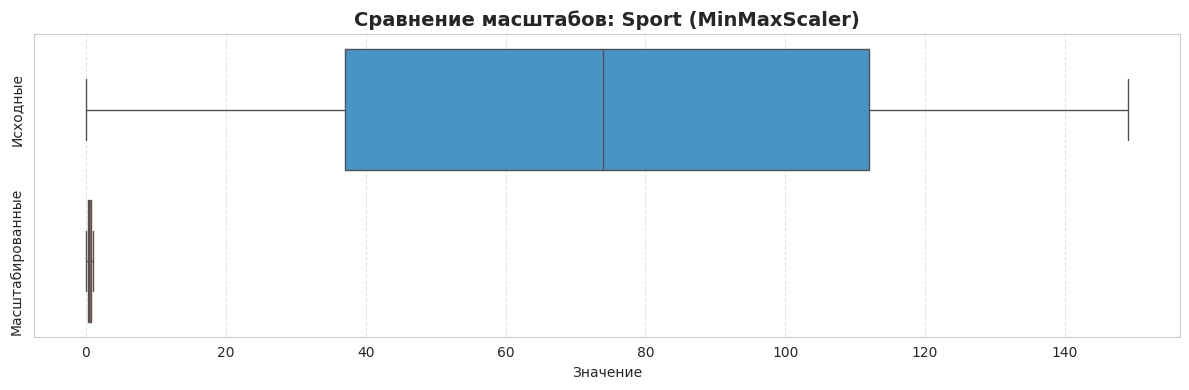

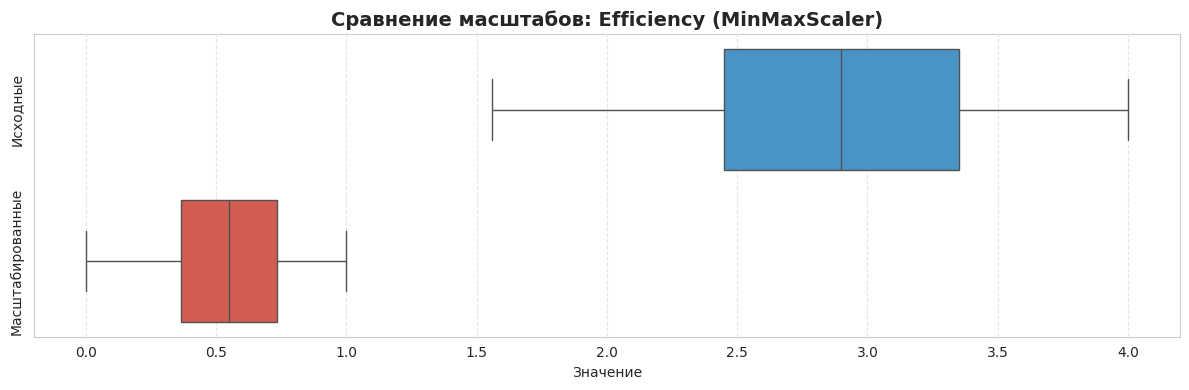

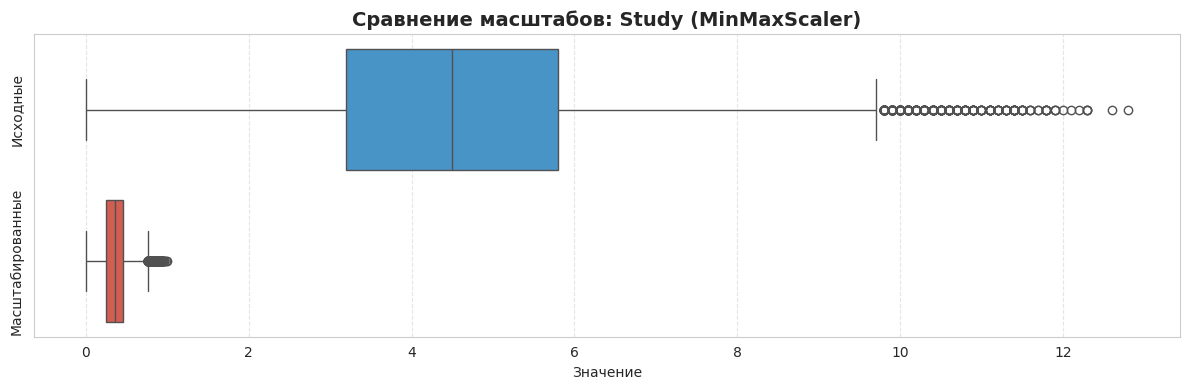

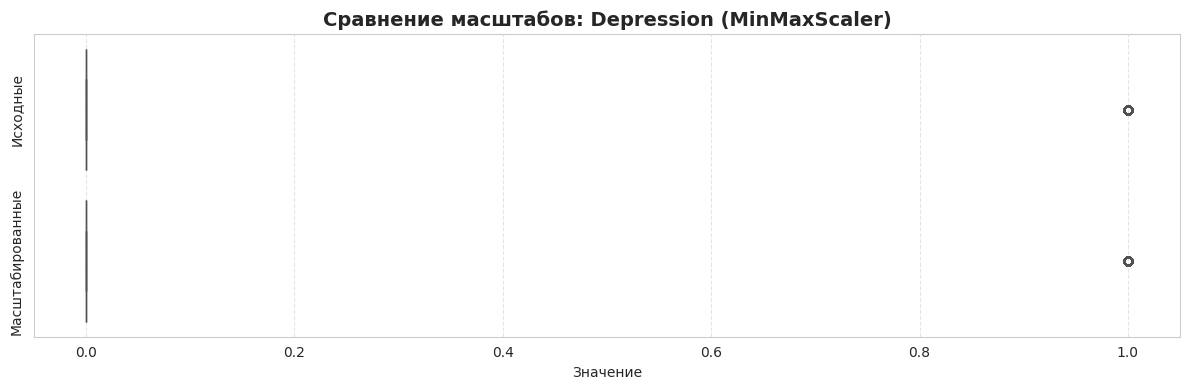

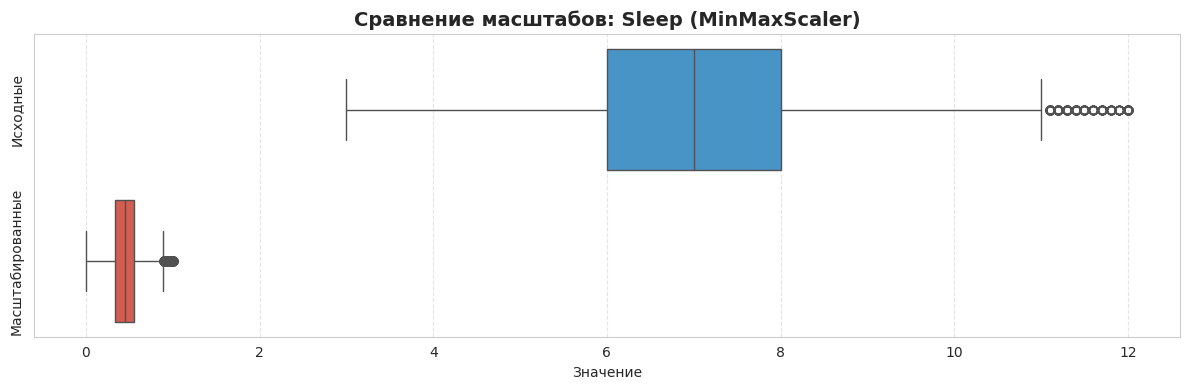

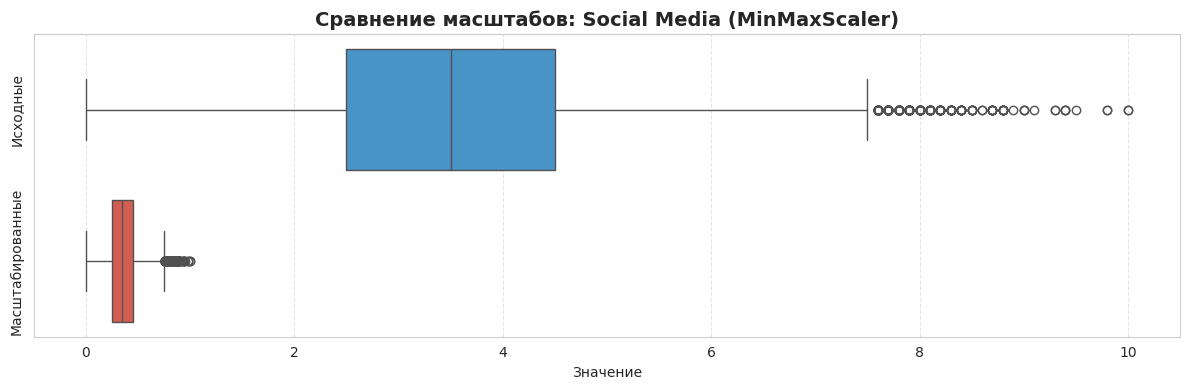

In [ ]:
def plot_comparison_single_canvas(original_df, scaled_df, title_method):
    for col in original_df.columns:
        plt.figure(figsize=(12, 4))  # Сделал чуть ниже для компактности

        data_to_plot = pd.DataFrame(
            {"Исходные": original_df[col], "Масштабированные": scaled_df[col]}
        )
        data_melted = data_to_plot.melt(var_name="Тип", value_name="Значение")

        sns.boxplot(
            data=data_melted,
            x="Значение",
            y="Тип",
            hue="Тип",
            palette=["#3498db", "#e74c3c"],
            legend=False,  # <--- ИСПРАВЛЕНИЕ: чтобы не было лишней легенды
        )

        # ПОВОРОТ ПОДПИСЕЙ ПО Y
        plt.yticks(rotation=90, verticalalignment="center")  # <--- ИСПРАВЛЕНИЕ

        plt.title(
            f"Сравнение масштабов: {col} ({title_method})",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Значение")
        plt.ylabel("")

        # СЕТКА ПО ОСИ X (так как значения теперь там)
        plt.grid(linestyle="--", axis="x", alpha=0.5)  # <--- ИСПРАВЛЕНИЕ

        plt.tight_layout()
        plt.show()


plot_comparison_single_canvas(df[numeric_columns], df_scaled_minmax, "MinMaxScaler")

## Обработка выбросов

In [112]:
numeric_cols = list(dict.fromkeys(numeric_cols).keys() - dict.fromkeys(cat_cols).keys())

print(numeric_cols)

['Sleep', 'Sport', 'Social Media', 'Efficiency', 'Study']


In [ ]:
from feature_engine.outliers import Winsorizer

# Ограничиваем выбросы (Winsorizing) - заменяем крайние значения на процентили
# Например, всё что ниже 5% и выше 95% обрезается
winsorizer = Winsorizer(
    capping_method="quantiles", tail="both", fold=0.05, variables=numeric_cols
)

df_winsorized = winsorizer.fit_transform(df)

## Кодирование категориальных признаков

In [123]:
from feature_engine.encoding import OneHotEncoder

ohe = OneHotEncoder(variables=cat_cols, drop_last=True)
df_encoded = ohe.fit_transform(df_winsorized)

## Линейная регрессия


📊 Метрики для Train:
  MAE:  0.44
  RMSE: 0.51
  R²:   0.0472
  MAPE: 15.75%

📊 Метрики для Test:
  MAE:  0.44
  RMSE: 0.51
  R²:   0.0413
  MAPE: 15.80%


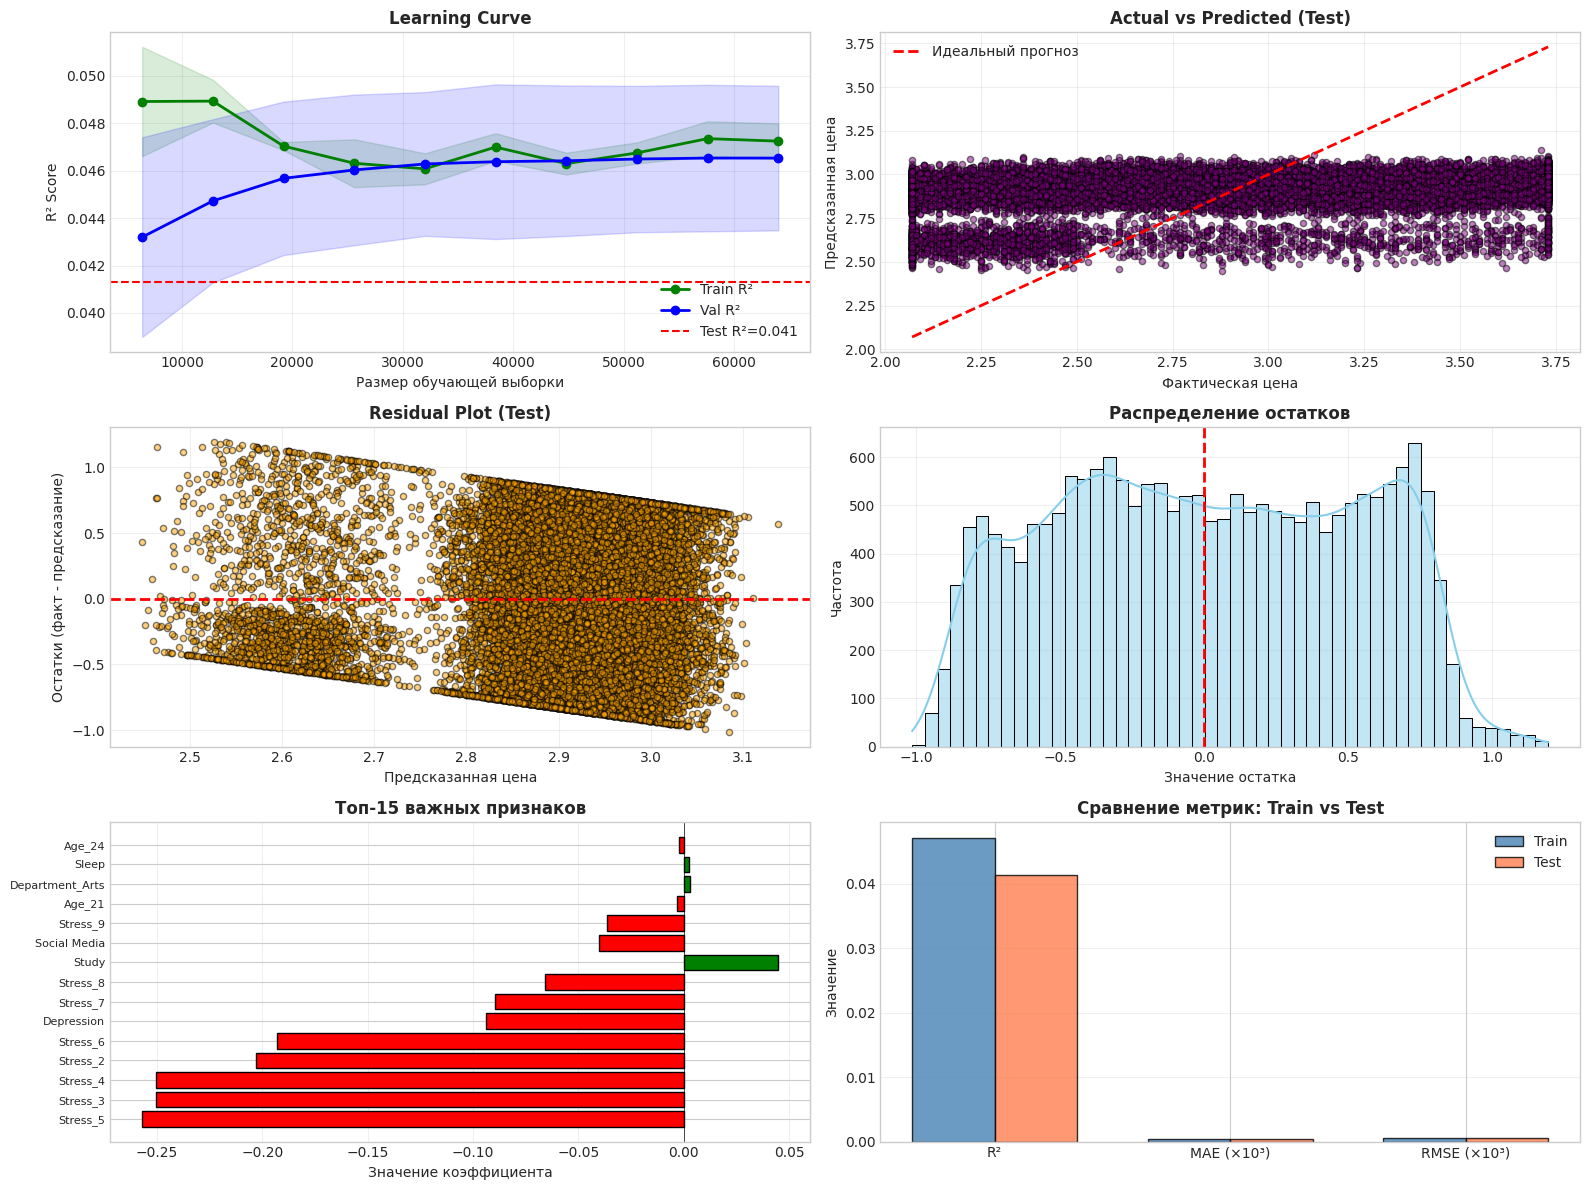


🔍 Диагностика:
  Разница R² (Train - Test): 0.0059
  ✅ Модель обобщает данные адекватно.

📈 Топ-10 факторов, УВЕЛИЧИВАЮЩИХ цену:
  + Study: 0.04
  + Department_Arts: 0.00
  + Sleep: 0.00

📉 Топ-10 факторов, УМЕНЬШАЮЩИХ цену:
  - Stress_5: -0.26
  - Stress_3: -0.25
  - Stress_4: -0.25
  - Stress_2: -0.20
  - Stress_6: -0.19
  - Depression: -0.09
  - Stress_7: -0.09
  - Stress_8: -0.07
  - Social Media: -0.04
  - Stress_9: -0.04


In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. Подготовка данных
# ============================================

# Целевая переменная
y = df_encoded["Efficiency"]
X = df_encoded.drop(columns=["Efficiency"])

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Масштабирование признаков (важно для интерпретации коэффициентов)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 2. Обучение модели
# ============================================

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================
# 3. Оценка качества модели
# ============================================


def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


# Оценка на обеих выборках
train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# ============================================
# 4. Визуализация результатов (2 графика в ряд)
# ============================================

from sklearn.model_selection import learning_curve

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 12))

# --- 4.1 Learning Curve (Кривая обучения) ---
ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2",
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, "o-", color="green", label="Train R²", linewidth=2)
ax1.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="green",
)
ax1.plot(train_sizes, val_mean, "o-", color="blue", label="Val R²", linewidth=2)
ax1.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="blue"
)
ax1.set_xlabel("Размер обучающей выборки", fontsize=10)
ax1.set_ylabel("R² Score", fontsize=10)
ax1.set_title("Learning Curve", fontsize=12, fontweight="bold")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.axhline(
    y=test_metrics["R2"],
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"Test R²={test_metrics['R2']:.3f}",
)
ax1.legend()

# --- 4.2 Actual vs Predicted ---
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors="black", s=20, color="purple")
ax2.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Идеальный прогноз",
)
ax2.set_xlabel("Фактическая цена", fontsize=10)
ax2.set_ylabel("Предсказанная цена", fontsize=10)
ax2.set_title("Actual vs Predicted (Test)", fontsize=12, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- 4.3 Остатки (Residuals) ---
ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors="black", s=20, color="orange")
ax3.axhline(y=0, color="red", linestyle="--", lw=2)
ax3.set_xlabel("Предсказанная цена", fontsize=10)
ax3.set_ylabel("Остатки (факт - предсказание)", fontsize=10)
ax3.set_title("Residual Plot (Test)", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3)

# --- 4.4 Распределение остатков ---
ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color="skyblue", edgecolor="black")
ax4.axvline(x=0, color="red", linestyle="--", lw=2)
ax4.set_xlabel("Значение остатка", fontsize=10)
ax4.set_ylabel("Частота", fontsize=10)
ax4.set_title("Распределение остатков", fontsize=12, fontweight="bold")
ax4.grid(True, alpha=0.3)

# --- 4.5 Коэффициенты модели (Топ-15 по модулю) ---
ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({"feature": X.columns, "coef": model.coef_})
coefficients = coefficients.sort_values(
    by="coef", key=lambda x: np.abs(x), ascending=False
).head(15)

colors = ["green" if c > 0 else "red" for c in coefficients["coef"]]
bars = ax5.barh(
    coefficients["feature"], coefficients["coef"], color=colors, edgecolor="black"
)
ax5.set_xlabel("Значение коэффициента", fontsize=10)
ax5.set_title("Топ-15 важных признаков", fontsize=12, fontweight="bold")
ax5.grid(True, alpha=0.3, axis="x")
ax5.axvline(x=0, color="black", lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

# --- 4.6 Сравнение метрик Train/Test ---
ax6 = plt.subplot(3, 2, 6)
metrics_names = ["R²", "MAE", "RMSE"]
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [
    train_metrics["R2"],
    train_metrics["MAE"] / 1000,
    train_metrics["RMSE"] / 1000,
]
test_vals = [
    test_metrics["R2"],
    test_metrics["MAE"] / 1000,
    test_metrics["RMSE"] / 1000,
]

ax6.bar(
    x_pos - width / 2,
    train_vals,
    width,
    label="Train",
    alpha=0.8,
    edgecolor="black",
    color="steelblue",
)
ax6.bar(
    x_pos + width / 2,
    test_vals,
    width,
    label="Test",
    alpha=0.8,
    edgecolor="black",
    color="coral",
)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(["R²", "MAE (×10³)", "RMSE (×10³)"])
ax6.set_ylabel("Значение", fontsize=10)
ax6.set_title("Сравнение метрик: Train vs Test", fontsize=12, fontweight="bold")
ax6.legend()
ax6.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("linear_regression_results.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================
# 5. Дополнительная диагностика
# ============================================

# Проверка на переобучение
r2_diff = train_metrics["R2"] - test_metrics["R2"]
print(f"\n🔍 Диагностика:")
print(f"  Разница R² (Train - Test): {r2_diff:.4f}")
if r2_diff > 0.1:
    print("  ⚠️  Возможное переобучение! Рассмотрите регуляризацию (Ridge/Lasso).")
elif r2_diff < -0.1:
    print("  ⚠️  Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("  ✅ Модель обобщает данные адекватно.")

# Топ-10 положительных и отрицательных факторов влияния на цену
print(f"\n📈 Топ-10 факторов, УВЕЛИЧИВАЮЩИХ цену:")
top_positive = coefficients[coefficients["coef"] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f"  + {row['feature']}: {row['coef']:.2f}")

print(f"\n📉 Топ-10 факторов, УМЕНЬШАЮЩИХ цену:")
top_negative = coefficients[coefficients["coef"] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f"  - {row['feature']}: {row['coef']:.2f}")